# V2_3 · Olsson — Mouse myeloid progenitors (SMART-Seq, including KOs)

**Data**: `olsson_tpm.h5ad` — 640 cells × ~24 k genes (WT 452 + single-KO 141
+ double-KO 47) with TPM in `.X`; `fig1b.tsv` provides the feature-gene set
from the paper's fig 1B (used as the ordering filter).

**This notebook**:
1. TPM → Census transcript counts → NB CellDataSet (all 640 cells)
2. Annotate experimental `Type`
3. Use the fig 1B feature genes directly as the ordering filter → DDRTree → `order_cells`
4. Visualise where the KO cells fall on the trajectory
5. State × Type distribution heatmap
6. BEAM at `branch_point=1` + branched heatmap
7. Single-gene branched pseudotime curves for erythroid vs granulocyte markers

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pheatmap import pheatmap

from monocle2py import (
    beam,
    differential_gene_test,
    estimate_size_factors,
    load_fig1b_ordering_genes,
    load_olsson_tpm,
    new_cell_dataset,
    order_cells,
    plot_cell_trajectory,
    plot_genes_branched_heatmap,
    plot_genes_branched_pseudotime,
    reduce_dimension,
    relative2abs,
    set_ordering_filter,
    tobit,
)
from monocle2py._uns import set_disp_fit_info

## 1. Load TPM expression and the fig 1B ordering genes

In [2]:
olsson = load_olsson_tpm()
fig1b_table = load_fig1b_ordering_genes()
# fig1b row 0 is the 'column_clusters-flat' header; gene symbols start at row 1.
fig1b_genes = fig1b_table['UID'].dropna().iloc[1:].astype(str).tolist()
print('TPM bundle:', olsson.shape)
print('fig1b feature genes:', len(fig1b_genes))

TPM bundle: (640, 23955)
fig1b feature genes: 532


## 2. TPM → Census transcript counts

Build a tobit CDS on TPM, run `relative2abs` for transcript counts, then
rebuild a negative-binomial CDS for the rest of the pipeline.

In [3]:
tpm_cds = new_cell_dataset(
    olsson.X, pheno_data=olsson.obs.copy(),
    feature_data=olsson.var.copy(),
    lower_detection_limit=0.1,
    expression_family=tobit(lower=0.1),
)
rpc = relative2abs(tpm_cds, method='num_genes')

cds = new_cell_dataset(
    rpc, pheno_data=olsson.obs.copy(),
    feature_data=olsson.var.copy(),
    lower_detection_limit=0.5,
)
estimate_size_factors(cds)
print('NB CDS:', cds.shape)

NB CDS: (640, 23955)


## 3. Annotate experimental `Type`

Cell-name prefixes encode condition (`Lsk` / `Cmp` / `Gmp` / `Gfi1.KO` etc.).
The columns are positionally ordered with rows 453–593 single-KO and 594–640
double-KO, matching the original Olsson 2016 metadata convention.

In [4]:
groups = pd.Series(
    cds.obs_names.str.split('.', n=2).str[:2].str.join('.'),
    index=cds.obs_names,
)
type_col = pd.Series(cds.obs_names.str.split('.', n=2).str[0],
                     index=cds.obs_names, dtype=object)
if cds.n_obs >= 593:
    type_col.iloc[452:593] = type_col.iloc[452:593] + '_knockout'
if cds.n_obs >= 640:
    second = pd.Series(cds.obs_names.str.split('.', n=2).str[1],
                       index=cds.obs_names)
    type_col.iloc[593:640] = (
        type_col.iloc[593:640] + '_' + second.iloc[593:640] + '_knockout'
    )
cds.obs['Type'] = type_col
cds.obs['Type'].value_counts()

Type
Gmp                            132
Cmp                             94
Lsk                             93
Gfi1_knockout                   79
LK                              63
Irf8_knockout                   62
GG1                             37
IG2                             33
Gfi1--Irf8--_E2_knockout         2
Gfi1--Irf8--_B1_knockout         1
Gfi1--Irf8--_D1_knockout         1
Gfi1--Irf8--_E1_knockout         1
Gfi1--Irf8--_Gfi11_knockout      1
Gfi1--Irf8--_C1_knockout         1
Gfi1--Irf8--_H1_knockout         1
Gfi1--Irf8--_A2_knockout         1
Gfi1--Irf8--_C2_knockout         1
Gfi1--Irf8--_B2_knockout         1
Gfi1--Irf8--_D2_knockout         1
Gfi1--Irf8--_Gfi12_knockout      1
Gfi1--Irf8--_A3_knockout         1
Gfi1--Irf8--_B3_knockout         1
Gfi1--Irf8--_E3_knockout         1
Gfi1--Irf8--_F3_knockout         1
Gfi1--Irf8--_Gfi13_knockout      1
Gfi1--Irf8--_H3_knockout         1
Gfi1--Irf8--_A4_knockout         1
Gfi1--Irf8--_B4_knockout         1
Gfi1--Irf8--_D4

## 4. Use the fig 1B feature genes as the ordering filter

The original tutorial reduces to a tSNE + density-peak cluster + `~Cluster`
DEG path on the WT subset. Here we use the paper's curated fig 1B gene set
directly — cleaner and reproducible.

In [5]:
ordering_genes = sorted(set(fig1b_genes) & set(cds.var_names))
set_ordering_filter(cds, ordering_genes)
print('ordering genes used:', len(ordering_genes))

ordering genes used: 532


## 5. Trajectory inference — DDRTree + `order_cells`

Default DDRTree parameters are used; the original tutorial's hand-tuned
`max_components=4, lambda=14*N, gamma=100` set was for the full 640-cell
MARS-seq scale and is not required for the smoke run here.

In [6]:
reduce_dimension(
    cds, max_components=2, reduction_method='DDRTree',
    auto_param_selection=True, max_iter=10, verbose=False,
)
order_cells(cds)
print('States:', sorted(cds.obs['State'].astype(int).unique().tolist()))

States: [1, 2, 3, 4, 5]


## 6. Trajectory visualisation — where do the KO cells fall?

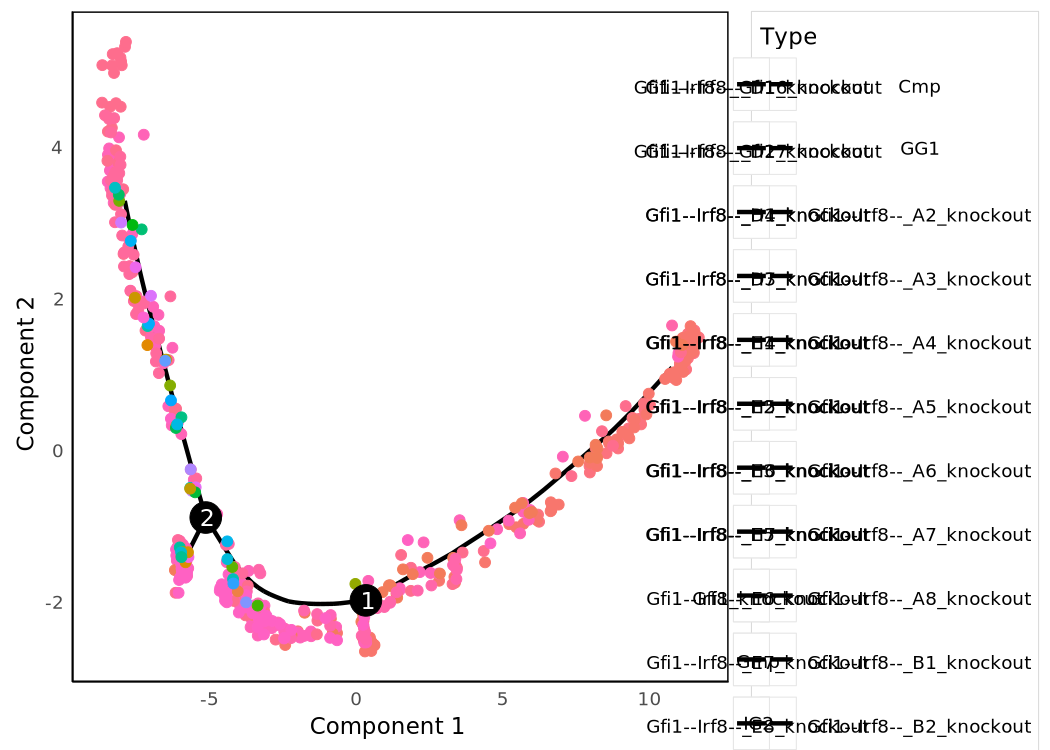

In [7]:
plot_cell_trajectory(cds, color_by='Type')

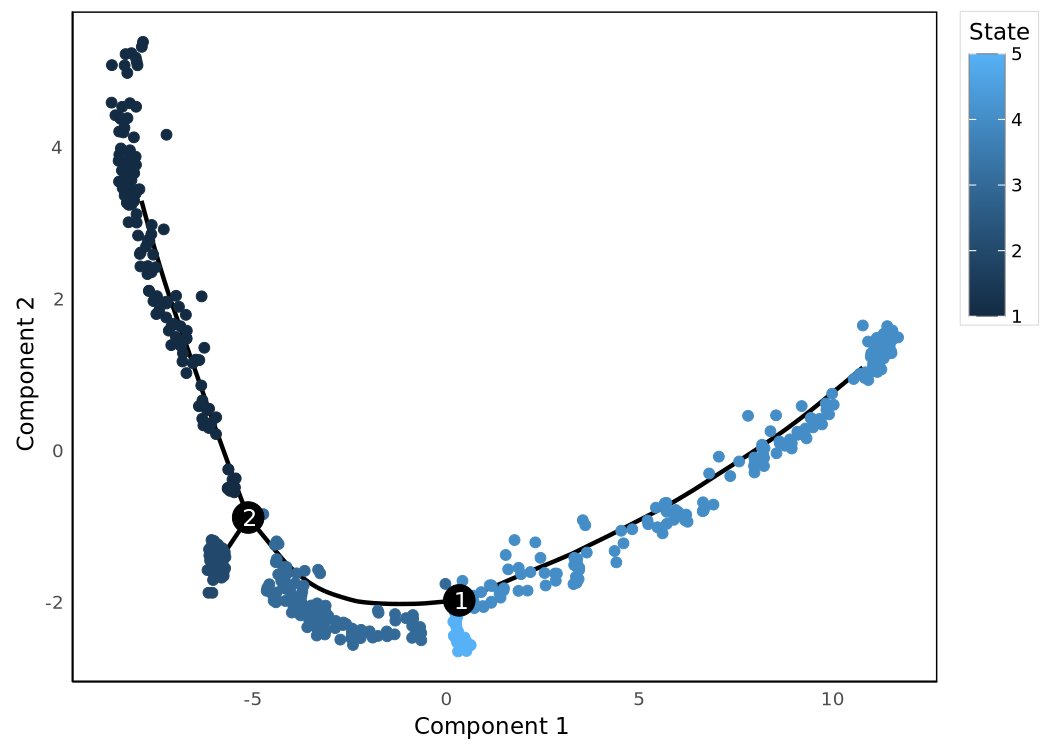

In [8]:
plot_cell_trajectory(cds, color_by='State', show_branch_points=True)

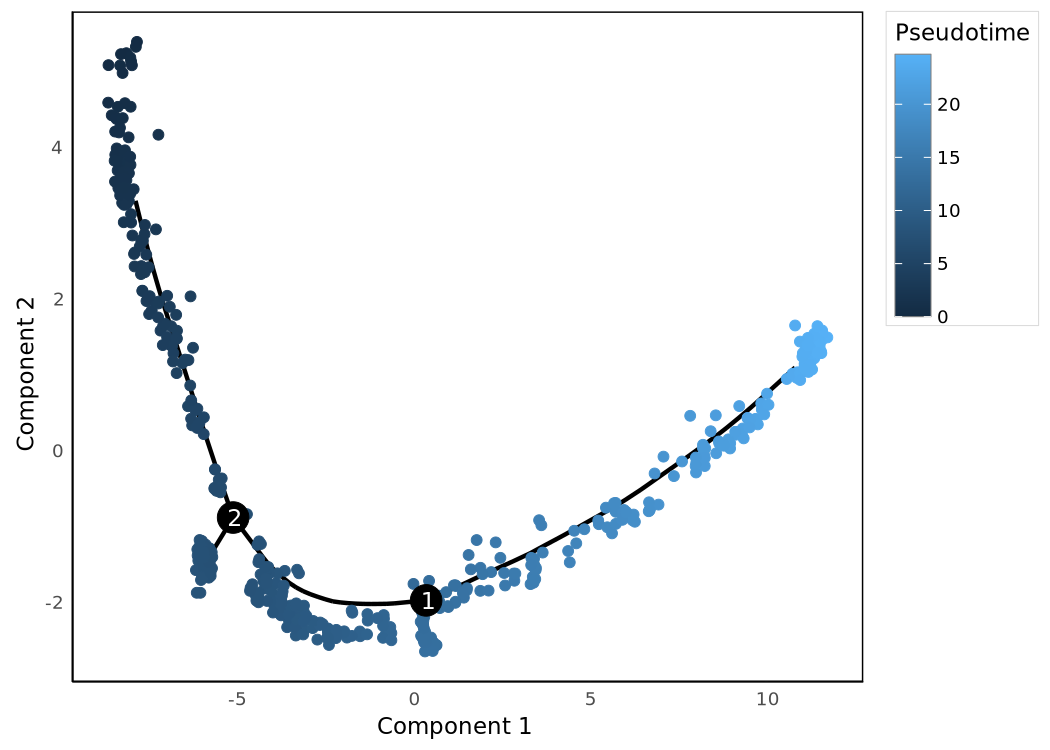

In [9]:
plot_cell_trajectory(cds, color_by='Pseudotime', show_branch_points=True)

## 7. State × Type distribution heatmap

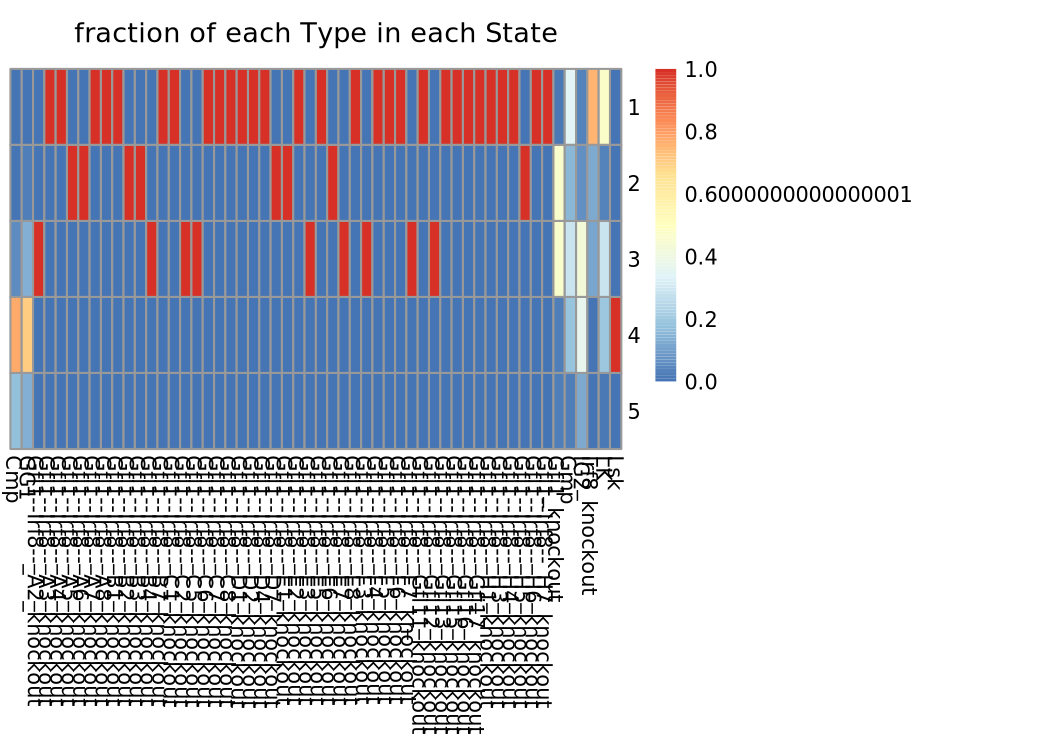

In [10]:
state_type = pd.crosstab(
    cds.obs['State'].astype(int), cds.obs['Type'],
)
frac = state_type.div(state_type.sum(axis=0), axis=1)
pheatmap(
    frac.to_numpy(), cluster_rows=False, cluster_cols=False,
    main='fraction of each Type in each State',
    labels_row=[str(s) for s in frac.index],
    labels_col=list(frac.columns),
)

## 8. BEAM — `branch_point = 1`

In [11]:
panel_idx = (
    cds.var.assign(n=cds.var['num_cells_expressed']
                  if 'num_cells_expressed' in cds.var
                  else (cds.X > 0).sum(axis=0))
       .sort_values('n', ascending=False).index[:300]
)
panel = cds[:, panel_idx].copy()
panel.uns['monocle2'] = dict(cds.uns['monocle2'])

def _disp_func(q):
    return 0.05 + 1.0 / np.asarray(q, dtype=float)
set_disp_fit_info(
    panel,
    {'disp_func': _disp_func,
     'coefficients': {'asymptDisp': 0.05, 'extraPois': 1.0},
     'disp_table': pd.DataFrame()},
    name='blind',
)
beam_res = beam(panel, branch_point=1).sort_values('qval')
print('qval < 1e-4:', int((beam_res['qval'] < 1e-4).sum()))
beam_res[['gene_short_name', 'pval', 'qval']].head(15)

qval < 1e-4: 1


,gene_short_name,pval,qval
gene_id,,,
Cybrd1,Cybrd1,1.205767e-07,0.000036
Malat1,Malat1,8.271196e-07,0.000124
Zfp488,Zfp488,2.421396e-06,0.000242
A130077B15Rik,A130077B15Rik,7.042424e-06,0.000528
Colec12,Colec12,1.055507e-04,0.004989
H2-T23,H2-T23,1.164089e-04,0.004989
Grk4,Grk4,1.069026e-04,0.004989
Dph5,Dph5,5.501647e-04,0.020631
Gpr157,Gpr157,9.257188e-04,0.027772


In [12]:
top_genes = beam_res[beam_res['qval'] < 1e-4].index.tolist()
if len(top_genes) >= 5:
    plot_genes_branched_heatmap(
        cds[:, top_genes], branch_point=1,
        num_clusters=4, use_gene_short_name=True,
        show_rownames=False,
    )
else:
    print('Fewer than 5 BEAM hits at qval<1e-4 — skipping heatmap.')

Fewer than 5 BEAM hits at qval<1e-4 — skipping heatmap.


## 9. Single-gene branched pseudotime curves

Erythroid (`Car1`, `Car2`) vs granulocyte (`Elane`, `Prtn3`) markers.

In [13]:
sel_short = ['Car1', 'Car2', 'Elane', 'Prtn3']
sel_genes = cds.var_names[cds.var['gene_short_name'].isin(sel_short)].tolist()
if sel_genes:
    plot_genes_branched_pseudotime(
        cds[:, sel_genes], branch_point=1,
        color_by='Type', ncol=2,
    )
else:
    print('Marker genes not present in the var index.')